In [3]:
import pandas as pd
import pyreadr
from deep_translator import GoogleTranslator
from joblib import Parallel, delayed
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM
from tqdm import tqdm
import torch
from langdetect import detect, DetectorFactory
from sacrebleu.metrics import BLEU
import random
import re
import pickle
import langid

In [ ]:
# caminho para o ficheiro .rds
file_path = 'C:\\Users\\marta\\Downloads\\EUPDCorp_1999-2024_v1.RDS'

# ler o ficheiro .rds
result = pyreadr.read_r(file_path)

# Quando se lê um .rds normalmente devolve um dict com chave None
df = result[None]

# Verificar os primeiros registos
df.head()

# Verificar os tipos de coluna
print(df.dtypes)

# Se quiseres, gravar para CSV para usar mais tarde
df.to_csv('EUPDCorp_dataset.csv', index=False)


doc_id                float64
file                   object
term_no              category
date                   object
datemonth             float64
year                  float64
agenda                 object
firstname              object
lastname               object
country                object
language               object
nationality            object
gender                float64
birth_year            float64
birth_place            object
mepid                 float64
moderator             float64
party_db_code          object
epg_short            category
epg_long               object
epg_partyfacts_id     float64
party_name             object
partyfacts_id        category
ches_id               float64
gps_id                float64
speech                 object
speech_en              object
dtype: object


In [2]:
df = pd.read_csv("EUPDCorp_dataset.csv")

In [3]:
df.describe()

,doc_id,term_no,datemonth,year,gender,birth_year,mepid,moderator,epg_partyfacts_id,partyfacts_id,ches_id,gps_id
count,563696.000000,563696.000000,563696.000000,563696.000000,563692.000000,563692.000000,563696.000000,563696.000000,547061.000000,563692.000000,286483.000000,492893.000000
mean,281977.453303,7.263873,201276.147376,2012.695586,0.645936,1961.035512,71889.333362,0.066282,6426.832181,1430.665995,1286.545973,541.405451
std,162754.913085,1.113587,546.165318,5.463053,0.478229,11.954513,57126.916493,0.248775,251.456952,1770.315824,839.272956,236.286389
min,1.000000,5.000000,199907.000000,1999.000000,0.000000,1922.000000,0.000000,0.000000,6398.000000,4.000000,102.000000,38.000000
25%,141071.750000,7.000000,201006.000000,2010.000000,0.000000,1953.000000,4555.000000,0.000000,6398.000000,365.000000,613.000000,333.000000
50%,281996.500000,7.000000,201404.000000,2014.000000,1.000000,1960.000000,96716.000000,0.000000,6399.000000,1022.000000,1102.000000,573.000000
75%,422921.250000,8.000000,201606.000000,2016.000000,1.000000,1970.000000,124742.000000,0.000000,6401.000000,1563.000000,2008.000000,720.000000
max,563846.000000,9.000000,202402.000000,2024.000000,1.000000,1998.000000,251324.000000,1.000000,8760.000000,9132.000000,4005.000000,909.000000


In [3]:

# =========================
# 3. Load NLLB
# =========================
model_name = "facebook/nllb-200-distilled-600M"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

if device == "cuda":
    model = model.half()

# =========================
# 4. Clean text
# =========================
def clean_text(text):

    if pd.isna(text):
        return ""

    text = str(text).strip()
    text = re.sub(r'\s+', ' ', text)

    return text

df["agenda_clean"] = df["agenda"].apply(clean_text)

# =========================
# 5. Unique agendas ONLY
# =========================
unique_agendas = df["agenda_clean"].dropna().unique()

# =========================
# 6. Language mapping
# =========================
lang_map = {
    "en": "eng_Latn",
    "fr": "fra_Latn",
    "de": "deu_Latn",
    "es": "spa_Latn",
    "it": "ita_Latn",
    "pt": "por_Latn",
    "da": "dan_Latn",
    "nl": "nld_Latn",
    "sv": "swe_Latn",
    "fi": "fin_Latn",
    "pl": "pol_Latn",
    "cs": "ces_Latn",
    "sk": "slk_Latn",
    "hu": "hun_Latn",
    "ro": "ron_Latn"
}

# =========================
# 7. Detect language CORRETAMENTE
# =========================
agenda_langs = {}

for text in tqdm(unique_agendas, desc="Detecting languages"):

    try:
        lang_code, score = langid.classify(text)

        nllb_lang = lang_map.get(lang_code, "eng_Latn")

    except:
        nllb_lang = "eng_Latn"

    agenda_langs[text] = nllb_lang

# =========================
# 8. Group by detected language
# =========================
lang_groups = {}

for text in unique_agendas:

    lang = agenda_langs[text]

    if lang not in lang_groups:
        lang_groups[lang] = []

    lang_groups[lang].append(text)

# =========================
# 9. Translation function
# =========================
def translate_batch(texts, src_lang, batch_size=64):

    tokenizer.src_lang = src_lang

    results = []

    for i in range(0, len(texts), batch_size):

        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        with torch.no_grad():

            outputs = model.generate(
                **inputs,
                forced_bos_token_id=tokenizer.lang_code_to_id["eng_Latn"],
                max_length=100
            )

        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)

        results.extend(decoded)

    return results

# =========================
# 10. Translation loop
# =========================
translations_dict = {}

for lang, texts in lang_groups.items():

    print(f"\nTranslating {len(texts)} items from {lang}")

    translated = translate_batch(texts, lang, batch_size=64)

    for original, trans in zip(texts, translated):
        translations_dict[original] = trans

# =========================
# 11. Apply translations
# =========================
df["agenda_en"] = df["agenda_clean"].map(translations_dict)

# =========================
# 12. Validation
# =========================
print("\nValidation sample:\n")

sample = df[["agenda", "agenda_en"]].drop_duplicates().sample(20)

for _, row in sample.iterrows():

    print("ORIGINAL :", row["agenda"])
    print("TRANSLATED:", row["agenda_en"])
    print("-"*50)

# =========================
# 13. Save
# =========================
df.to_csv("EUPDCorp_agenda_fixed.csv", index=False)

print("\nDone ✅")

Detecting languages: 100%|██████████| 14620/14620 [02:38<00:00, 92.39it/s] 



Translating 1714 items from dan_Latn


the `lang_code_to_id` attribute is deprecated. The logic is natively handled in the `tokenizer.adder_tokens_decoder` this attribute will be removed in `transformers` v4.38



Translating 55 items from swe_Latn

Translating 11809 items from eng_Latn

Translating 291 items from deu_Latn

Translating 141 items from spa_Latn

Translating 81 items from nld_Latn

Translating 87 items from ita_Latn

Translating 25 items from ces_Latn

Translating 142 items from fra_Latn

Translating 12 items from slk_Latn

Translating 88 items from pol_Latn

Translating 60 items from fin_Latn

Translating 33 items from ron_Latn

Translating 36 items from por_Latn

Translating 46 items from hun_Latn

Validation sample:

ORIGINAL : Preparation of the G7 Summit (debate)
TRANSLATED: Preparation of the G7 Summit (debate)
--------------------------------------------------
ORIGINAL : Statistics relating to external trade with non-member countries (delegated and implementing powers) (A8-0240/2016 - Bernd Lange)
TRANSLATED: Statistics relating to external trade with third countries (delegated and implementing powers) (A8-0240/2016 - Bernd Lange)
-------------------------------------------

In [214]:
df = pd.read_csv("EUPDCorp_agenda_fixed.csv")

#df.head(30)

In [220]:
# =========================================================
# 2. CLEAN TEXT
# =========================================================

def clean_text(text):

    if pd.isna(text):
        return ""

    text = str(text).lower()

    # remover espaços extra
    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["agenda_en_clean"] = df["agenda_en"].apply(clean_text)
df["speech_en_clean"] = df["speech_en"].apply(clean_text)

# =========================================================
# 3. DEFINIR PERÍODOS
# =========================================================

def define_period(year):

    if 2015 <= year <= 2016:
        return "migration_crisis"

    elif year >= 2022:
        return "ukraine_refugees"

    return "other"

df["period"] = df["year"].apply(define_period)

# =========================================================
# 4. KEYWORDS
# =========================================================

# -------------------------
# migration keywords
# -------------------------
migration_terms = [
    "migration", "migrant", "migrants",
    "immigration", "immigrant", "immigrants",
    "asylum", "asylum seeker", "asylum seekers",
    "refugee", "refugees",
    "displaced", "displacement",
    "forced migration",
    "international protection",
    "temporary protection",
    "migration policy",
    "asylum policy",
    "refugee policy",
    "border management",
    "border control",
    "external borders",
    "irregular migration",
    "illegal migration",
    "smuggling",
    "human trafficking",
    "migration flows", 
    "humanitarian",
    "humanitarian aid",
    "humanitarian assistance",
    "humanitarian crisis",
    "humanitarian protection",
    "humanitarian response",
    "emergency response",
    "fleeing war",
    "fleeing conflict",
    "mass displacement",
    "forced displacement",
    "people fleeing",
    "civilian protection"
]

# =========================================================
# 5. FUNÇÃO DE MATCH
# =========================================================

def contains_keywords(text, keywords):

    text = str(text).lower()

    return any(keyword in text for keyword in keywords)

# =========================================================
# 6. AGENDA FILTERS
# =========================================================

def migration_agenda(row):

    if row["period"] != "migration_crisis":
        return False

    return contains_keywords(
        row["agenda_en_clean"],
        migration_terms
    )

# -------------------------

def ukraine_agenda(row):

    if row["period"] != "ukraine_refugees":
        return False

    return contains_keywords(
        row["agenda_en_clean"],
        migration_terms
    )

# =========================================================
# 7. SPEECH FILTERS
# =========================================================

def migration_speech(row):

    if row["period"] != "migration_crisis":
        return False

    return contains_keywords(
        row["speech_en_clean"],
        migration_terms
    )

# -------------------------

def ukraine_speech(row):

    if row["period"] != "ukraine_refugees":
        return False

    return contains_keywords(
        row["speech_en_clean"],
        migration_terms
    )

# =========================================================
# 8. APPLY FILTERS
# =========================================================

print("Applying filters...")

df["migration_agenda"] = df.apply(
    migration_agenda,
    axis=1
)

df["ukraine_agenda"] = df.apply(
    ukraine_agenda,
    axis=1
)

df["migration_speech"] = df.apply(
    migration_speech,
    axis=1
)

df["ukraine_speech"] = df.apply(
    ukraine_speech,
    axis=1
)

# =========================================================
# 9. FINAL THESIS DATASET
# =========================================================

thesis_df = df[
    (
        (df["period"] == "migration_crisis") &
        (
            df["migration_agenda"] |
            df["migration_speech"]
        )
    )
    |
    (
        (df["period"] == "ukraine_refugees") &
        (
            df["ukraine_agenda"] |
            df["ukraine_speech"]
        )
    )
].copy()

# =========================================================
# 10. CREATE FINAL TOPIC VARIABLE
# =========================================================

def final_topic(row):

    if row["period"] == "migration_crisis":
        return "migration_2015"

    elif row["period"] == "ukraine_refugees":
        return "ukraine_refugees"

    return "other"

thesis_df["topic"] = thesis_df.apply(final_topic, axis=1)

# =========================================================
# 11. QUICK VALIDATION
# =========================================================

print("\n=========================")
print("TOPIC COUNTS")
print("=========================\n")

print(thesis_df["topic"].value_counts())

# -------------------------

print("\n=========================")
print("PERIOD COUNTS")
print("=========================\n")

print(thesis_df["period"].value_counts())

# -------------------------

print("\n=========================")
print("SAMPLE RESULTS")
print("=========================\n")

sample = thesis_df[
    [
        "year",
        "topic",
        "agenda_en",
        "speech_en"
    ]
].sample(20)

for _, row in sample.iterrows():

    print(f"YEAR: {row['year']}")
    print(f"TOPIC: {row['topic']}")
    print(f"AGENDA: {row['agenda_en']}")
    print("-" * 80)

# =========================================================
# 12. SAVE
# =========================================================

thesis_df.to_csv(
    "EUPDCorp_thesis_dataset.csv",
    index=False
)

print("\nDataset saved successfully ✅")
print(f"Final observations: {len(thesis_df)}")

Applying filters...

TOPIC COUNTS

topic
migration_2015      21550
ukraine_refugees     3635
Name: count, dtype: int64

PERIOD COUNTS

period
migration_crisis    21550
ukraine_refugees     3635
Name: count, dtype: int64

SAMPLE RESULTS

YEAR: 2015.0
TOPIC: migration_2015
AGENDA: Use of genetically modified food and feed (A8-0305/2015 - Giovanni La Via)
--------------------------------------------------------------------------------
YEAR: 2022.0
TOPIC: ukraine_refugees
AGENDA: Russia's escalation of its war of aggression against Ukraine (debate)
--------------------------------------------------------------------------------
YEAR: 2016.0
TOPIC: migration_2015
AGENDA: Communication on the implementation of the European agenda on migration (debate)
--------------------------------------------------------------------------------
YEAR: 2015.0
TOPIC: migration_2015
AGENDA: The Commission will also be able to take into account the information provided by the Commission on the implementation o

In [224]:
year_counts = (
    thesis_df.groupby("year")
    .size()
    .reset_index(name="Number_of_Speeches")
    .sort_values("year")
)

year_counts["Percentage"] = (
    year_counts["Number_of_Speeches"] /
    year_counts["Number_of_Speeches"].sum() * 100
).round(2)

# adicionar linha total
total_row = pd.DataFrame({
    "year": ["Total"],
    "Number_of_Speeches": [year_counts["Number_of_Speeches"].sum()],
    "Percentage": [100.0]
})

year_counts_final = pd.concat(
    [year_counts, total_row],
    ignore_index=True
)


year_counts_final.columns = [
    "Year",
    "Number of Speeches",
    "Percentage (%)"
]

year_counts_final

,Year,Number of Speeches,Percentage (%)
0,2015.0,8813,34.99
1,2016.0,12737,50.57
2,2022.0,2109,8.37
3,2023.0,1290,5.12
4,2024.0,236,0.94
5,Total,25185,100.00


In [225]:
df = pd.read_csv("EUPDCorp_thesis_dataset.csv")

In [226]:

df['speech_en'].value_counts().head(50)

speech_en
in writing. ‒ UKIP voted against this legislative vote regarding the granting of short term visas. Although this vote only relates to the Schengen area, which the UK is not part of, UKIP opposes the principle that the EU can decide immigration policy for any Member State. The only people who should decide immigration policy and visas are nationally elected and accountable governments, not undemocratic EU institutions in Brussels.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

Data Analysis and Cleaning

In [227]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25185 entries, 0 to 25184
Data columns (total 37 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   doc_id             25185 non-null  float64
 1   file               25185 non-null  object 
 2   term_no            25185 non-null  int64  
 3   date               25185 non-null  object 
 4   datemonth          25185 non-null  float64
 5   year               25185 non-null  float64
 6   agenda             25185 non-null  object 
 7   firstname          25185 non-null  object 
 8   lastname           25185 non-null  object 
 9   country            25185 non-null  object 
 10  language           25185 non-null  object 
 11  nationality        25185 non-null  object 
 12  gender             25185 non-null  float64
 13  birth_year         25185 non-null  float64
 14  birth_place        25185 non-null  object 
 15  mepid              25185 non-null  float64
 16  moderator          251

In [11]:
from graphviz import Digraph

dot = Digraph()

dot.node("A", "EUPDCORP Corpus")
dot.node("B", "Preprocessing\n(lowercase, clean text)")
dot.node("C", "Temporal Filtering\n(2015–2016 / 2022+)")
dot.node("D", "Keyword Filtering\n(agenda + speech)")
dot.node("E", "Final Dataset")

dot.edges(["AB", "BC", "CD", "DE"])

dot.render("pipeline_diagram", format="png", cleanup=True)

'pipeline_diagram.png'

Modelos

In [8]:
df = df[
    df["speech_en_clean"].str.split().str.len() >= 20
]

len(df)

25114

In [229]:
docs = df["speech_en_clean"].tolist()

# =========================================================
# 14. EMBEDDINGS (Sentence-BERT)
# =========================================================

from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-mpnet-base-v2")

embeddings = model.encode(
    docs,
    show_progress_bar=True,
    batch_size=64
)

print("Embeddings shape:", embeddings.shape)

Batches:   0%|          | 0/393 [00:00<?, ?it/s]

Embeddings shape: (25114, 768)


In [231]:
import numpy as np

np.save("embeddings_mpnet.npy", embeddings)

print("Embeddings saved successfully.")

Embeddings saved successfully.


In [17]:
import numpy as np

embeddings = np.load("embeddings_mpnet.npy")
#df = pd.read_csv("EUPDCorp_thesis_dataset.csv")
docs = df["speech_en_clean"].tolist()

print(embeddings.shape)


(25114, 768)


In [18]:
print(type(docs))
print(embeddings.shape)
print(len(df))

<class 'list'>
(25114, 768)
25114


In [12]:
from bertopic import BERTopic
from hdbscan import HDBSCAN

hdbscan_model = HDBSCAN(
    min_cluster_size=150,
    min_samples=20,
    prediction_data=True
)

topic_model = BERTopic(
    language="english",
    hdbscan_model=hdbscan_model,
    calculate_probabilities=False,
    verbose=True
)

#topics, probs = topic_model.fit_transform(
 #   docs,
  #  embeddings
#)

In [244]:
topic_info = topic_model.get_topic_info()

topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,7273,-1_the_of_and_to,"[the, of, and, to, in, is, that, for, we, on]","[i am sorry, but i have to say that i am not i..."
1,0,1100,0_syria_the_in_and,"[syria, the, in, and, to, humanitarian, of, is...",[vice-president of the commission/high represe...
2,1,1013,1_turkey_the_is_to,"[turkey, the, is, to, of, and, that, in, turki...",[for the vp/hr. mr president! i would also lik...
3,2,947,2_budget_the_for_to,"[budget, the, for, to, in, and, of, that, we, ...",[president-in-office of the council. – madam p...
4,3,938,3_ukraine_we_and_to,"[ukraine, we, and, to, the, war, of, our, is, ...",[prime minister of estonia. – honourable presi...
5,4,760,4_the_we_to_that,"[the, we, to, that, and, of, is, you, european...",[acting president of the council. madam presid...
6,5,731,5_budget_amending_eur_the,"[budget, amending, eur, the, million, in, to, ...",[in writing. ‒ i am in favour of draft amendin...
7,6,677,6_rights_human_of_and,"[rights, human, of, and, the, in, report, fund...",[vice-president of the commission/high represe...
8,7,505,7_border_borders_schengen_external,"[border, borders, schengen, external, the, gua...",[in writing. ‒ i supported the proposal as it ...
9,8,503,8_mediterranean_and_to_the,"[mediterranean, and, to, the, we, of, is, sea,...","[member of the commission. - madam president, ..."


In [245]:
for topic in topic_model.get_topic_info().Topic:
    print(topic, topic_model.get_topic(topic))

-1 [('the', 0.018933019321637806), ('of', 0.017079821196715125), ('and', 0.016797412648443907), ('to', 0.016614962978666336), ('in', 0.015593742390917889), ('is', 0.01359100424081616), ('that', 0.013306952076405108), ('for', 0.012116561849671113), ('we', 0.01172498250600356), ('on', 0.011406816949790363)]
0 [('syria', 0.02404707020904798), ('the', 0.01909232957099453), ('in', 0.018424050999249847), ('and', 0.018106986681817296), ('to', 0.01698442982640078), ('humanitarian', 0.016208699445397042), ('of', 0.01591627733859051), ('is', 0.014343626361316673), ('iraq', 0.01353219835509075), ('syrian', 0.0131229549318367)]
1 [('turkey', 0.039647985790014356), ('the', 0.019010698459218423), ('is', 0.017377752388863268), ('to', 0.017158643218667606), ('of', 0.015724707935467718), ('and', 0.015665238729524255), ('that', 0.014695455795123031), ('in', 0.01365143960384207), ('turkish', 0.013474590526375013), ('we', 0.013468284932834121)]
2 [('budget', 0.033262539110482846), ('the', 0.02271088839618

In [246]:
topic_model.visualize_topics()
topic_model.visualize_barchart(top_n_topics=10)

In [28]:
from bertopic import BERTopic
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_model = CountVectorizer(stop_words="english")

hdbscan_model = HDBSCAN(
    min_cluster_size=150,
    min_samples=20,
    prediction_data=True
)

topic_model2 = BERTopic(
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=False
)

topics, probs = topic_model2.fit_transform(
    docs,
    embeddings
)

In [61]:
for topic in topic_model2.get_topic_info().Topic:
    print(topic, topic_model2.get_topic(topic))

topic_model2.save("topic_model2")

2026-06-29 03:39:44,647 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


-1 [('european', 0.013050923017811288), ('eu', 0.010065621978389278), ('union', 0.00971693679836107), ('countries', 0.009561320377071351), ('report', 0.009371516947307522), ('states', 0.00932271313036452), ('writing', 0.009253322588603542), ('member', 0.009249029045758243), ('migration', 0.00902006364663354), ('commission', 0.009007298337474857)]
0 [('syria', 0.0400520939443877), ('humanitarian', 0.02503467175187538), ('iraq', 0.02363878578520754), ('syrian', 0.022705168089831095), ('lebanon', 0.01624709780107612), ('international', 0.01502051708908659), ('conflict', 0.014010262393683512), ('aid', 0.013028917827360192), ('resolution', 0.013003817428446678), ('region', 0.012741600477992252)]
1 [('europe', 0.01723611238675088), ('refugees', 0.017180388416984185), ('asylum', 0.016390512175470513), ('european', 0.01533557377010065), ('people', 0.01400448862341353), ('migration', 0.013306076683054491), ('need', 0.01287170701728422), ('member', 0.012610201909063605), ('states', 0.01251077791

In [62]:
from bertopic import BERTopic
topic_model2 = BERTopic.load("topic_model2")


In [30]:
topic_model2.visualize_topics()
topic_model2.visualize_barchart(top_n_topics=45)

In [60]:
# adicionar topic assignment ao dataset
df = df.copy()
df["topic"] = topics

df.to_csv(
    "Topic_dataset.csv",
    index=False
)

df

,doc_id,file,term_no,date,datemonth,year,agenda,firstname,lastname,country,...,agenda_clean,agenda_en,agenda_en_clean,speech_en_clean,period,migration_agenda,ukraine_agenda,migration_speech,ukraine_speech,topic
0,296742.0,CRE-8-2015-01-12-REV,8,2015-01-12,201501.0,2015.0,Statements by the President,Nigel,Farage,GBR,...,Statements by the President,Statements by the President,statements by the president,"on behalf of the efdd group. – mr president, i...",migration_crisis,False,False,True,False,11
1,296754.0,CRE-8-2015-01-12-REV,8,2015-01-12,201501.0,2015.0,One-minute speeches on matters of political im...,Csaba,Molnár,HUN,...,One-minute speeches on matters of political im...,One-minute speeches on matters of political im...,one-minute speeches on matters of political im...,"madam president, please. i would like to start...",migration_crisis,False,False,True,False,10
2,296755.0,CRE-8-2015-01-12-REV,8,2015-01-12,201501.0,2015.0,One-minute speeches on matters of political im...,Angel,Dzhambazki,BGR,...,One-minute speeches on matters of political im...,One-minute speeches on matters of political im...,one-minute speeches on matters of political im...,"madam president, in the light of the events in...",migration_crisis,False,False,True,False,-1
3,296756.0,CRE-8-2015-01-12-REV,8,2015-01-12,201501.0,2015.0,One-minute speeches on matters of political im...,Beatriz,Becerra Basterrechea,ESP,...,One-minute speeches on matters of political im...,One-minute speeches on matters of political im...,one-minute speeches on matters of political im...,"madam president, in venezuela there is politic...",migration_crisis,False,False,True,False,34
4,296763.0,CRE-8-2015-01-12-REV,8,2015-01-12,201501.0,2015.0,One-minute speeches on matters of political im...,Catherine,Stihler,GBR,...,One-minute speeches on matters of political im...,One-minute speeches on matters of political im...,one-minute speeches on matters of political im...,"madam president, i want to raise in the chambe...",migration_crisis,False,False,True,False,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25180,563768.0,CRE-9-2024-02-08-REV,9,2024-02-08,202402.0,2024.0,Working conditions of teachers in the EU (debate),André,Rougé,FRA,...,Working conditions of teachers in the EU (debate),The Commission's proposal for a directive on t...,the commission's proposal for a directive on t...,"mr president, ladies and gentlemen, how far wi...",ukraine_refugees,False,False,False,True,4
25181,563775.0,CRE-9-2024-02-08-REV,9,2024-02-08,202402.0,2024.0,Working conditions of teachers in the EU (debate),Marie,Dauchy,LUX,...,Working conditions of teachers in the EU (debate),The Commission's proposal for a directive on t...,the commission's proposal for a directive on t...,"mr president, today, 8 february 2024, we have ...",ukraine_refugees,False,False,False,True,24
25182,563818.0,CRE-9-2024-02-08-REV,9,2024-02-08,202402.0,2024.0,Association agreements for the participation o...,Seán,Kelly,IRL,...,Association agreements for the participation o...,The Commission is therefore prepared to adopt ...,the commission is therefore prepared to adopt ...,"mr president, this is a very important discuss...",ukraine_refugees,False,False,False,True,3
25183,563833.0,CRE-9-2024-02-08-REV,9,2024-02-08,202402.0,2024.0,The case of Dentsu tracking and the lack of tr...,Joachim,Kuhs,DEU,...,The case of Dentsu tracking and the lack of tr...,The case of Dentsu tracking and the lack of tr...,the case of dentsu tracking and the lack of tr...,"mr president, commissioner, ladies and gentlem...",ukraine_refugees,False,False,False,True,23


In [32]:
topic_info2 = topic_model2.get_topic_info()

plot_df = topic_info2[topic_info2["Topic"] != -1].head(15)

plot_df

,Topic,Count,Name,Representation,Representative_Docs
1,0,1110,0_syria_humanitarian_iraq_syrian,"[syria, humanitarian, iraq, syrian, lebanon, i...",[in writing. the ongoing violence in syria has...
2,1,1017,1_europe_refugees_asylum_european,"[europe, refugees, asylum, european, people, m...","[member of the commission.– mr president, firs..."
3,2,970,2_ukraine_war_ukrainian_russian,"[ukraine, war, ukrainian, russian, russia, ene...",[president-in-office of the council. – madam p...
4,3,882,3_budget_financial_mff_multiannual,"[budget, financial, mff, multiannual, framewor...",[in writing. ‒ i supported the motion for a re...
5,4,829,4_europe_european_union_presidency,"[europe, european, union, presidency, presiden...",[president-in-office of the council. madam pre...
6,5,768,5_turkey_turkish_accession_european,"[turkey, turkish, accession, european, turkeys...",[written. ‒ accession negotiations with turkey...
7,6,644,6_rights_human_fundamental_report,"[rights, human, fundamental, report, democracy...",[in writing. ‒ i am pleased to introduce parli...
8,7,600,7_budget_amending_eur_draft,"[budget, amending, eur, draft, million, approp...",[in writing. ‒ the european union is currently...
9,8,599,8_visa_agreement_waiver_shortstay,"[visa, agreement, waiver, shortstay, travel, v...",[in writing. ‒ the agreement on the short-stay...
10,9,517,9_mediterranean_sea_rescue_lives,"[mediterranean, sea, rescue, lives, people, mi...",[vice-president of the commission. – mr presid...


In [43]:
import pandas as pd

# Ensure consistency with BERTopic output
topic_info = topic_model2.get_topic_info()

n_docs = len(df)

n_outliers = (df["topic"] == -1).sum()

n_assigned = n_docs - n_outliers

pct_assigned = n_assigned / n_docs * 100

n_topics = topic_info[topic_info["Topic"] != -1].shape[0]

summary = pd.DataFrame({
    "Indicator": [
        "Number of speeches",
        "Number of substantive topics identified",
        "Outlier documents (Topic -1)",
        "Assigned documents (excluding outliers)",
        "Percentage assigned to substantive topics"
    ],
    "Value": [
        n_docs,
        n_topics,
        n_outliers,
        n_assigned,
        round(pct_assigned, 1)
    ]
})

summary

,Indicator,Value
0,Number of speeches,25114.0
1,Number of substantive topics identified,47.0
2,Outlier documents (Topic -1),7359.0
3,Assigned documents (excluding outliers),17755.0
4,Percentage assigned to substantive topics,70.7


In [41]:
import pandas as pd

# =========================
# 1. Topic info from BERTopic
# =========================
topic_info = topic_model2.get_topic_info()

# =========================
# 2. Remove outliers (-1)
# =========================
topic_info_clean = topic_info[topic_info["Topic"] != -1].copy()

# =========================
# 3. Total de documentos (SEM outliers)
# =========================
total_docs = topic_info_clean["Count"].sum()

# =========================
# 4. Percentagem correta
# =========================
topic_info_clean["Percentage"] = (
    topic_info_clean["Count"] / total_docs * 100
).round(2)

# =========================
# 5. Labels manuais (coloca aqui os teus)
# =========================
topic_labels = {
    0: "Syrian Refugee Crisis and Humanitarian Response",
    1: "European Asylum and Migration Policy",
    2: "Ukraine War and Energy Crisis",
    3: "EU Budget and Multiannual Financial Framework",
    4: "EU Institutional Affairs and Presidency",
    5: "EU–Turkey Relations and Accession",
    6: "Human Rights and Democratic Governance",
    7: "EU Budget Amendments and Financing",
    8: "Visa Policy and Security Cooperation",
    9: "Mediterranean Search and Rescue Operations",
    10: "Rule of Law in Hungary and Poland",
    11: "Security, Terrorism and Radicalisation",
    12: "Israel–Palestine Conflict",
    13: "EU Budget Discharge and Financial Oversight",
    14: "Human Trafficking and Exploitation",
    15: "Macro-Financial Assistance and Third Countries",
    16: "Border Management and Frontex Operations",
    17: "EU Blue Card and Labour Migration Scheme",
    18: "Gender Equality and Women's Rights",
    19: "Common Foreign and Security Policy (CFSP)",
    20: "Yemen Humanitarian Crisis",
    21: "EU Financial Flexibility Instruments",
    22: "Western Balkans Enlargement Process",
    23: "Illicit Tobacco Trade and Smuggling",
    24: "Education, Youth and Skills Development",
    25: "Relocation and Resettlement Mechanisms",
    26: "Women, Asylum and Vulnerability",
    27: "Agriculture and Food Policy",
    28: "Libya Conflict and Governance",
    29: "Maritime Safety and Frontex Accountability",
    30: "Parliamentary Resolutions on Migration",
    31: "EU Trust Fund for Africa and Development Aid",
    32: "Refugee Integration and Labour Market Inclusion",
    33: "Fundamental Rights and Ombudsman Oversight",
    34: "Migration and International Mobility Governance",
    35: "Development Policy and Sustainability",
    36: "Afghanistan and Voluntary Return Policies",
    37: "Humanitarian Aid and Global Summits",
    38: "Labour Markets and Social Inclusion",
    39: "Unaccompanied Minors and Child Protection",
    40: "Migration Reporting and Parliamentary Votes",
    41: "Visa Policy and Suspension Mechanisms",
    42: "Labour Rights and Undeclared Work",
    43: "Humanitarian Violence and Conflict Zones (DRC)",
    44: "United Nations and Global Governance",
    45: "Democratic Republic of Congo Conflict",
    46: "Climate Change and Energy Transition"
}

# =========================
# 6. Adicionar labels
# =========================
topic_info_clean["Label"] = topic_info_clean["Topic"].map(topic_labels)

# =========================
# 7. Função keywords BERTopic
# =========================
def extract_keywords(topic_model, topic_id, top_n=8):
    words = topic_model.get_topic(topic_id)
    if words:
        return ", ".join([w for w, _ in words[:top_n]])
    return ""

topic_info_clean["Top Keywords"] = topic_info_clean["Topic"].apply(
    lambda x: extract_keywords(topic_model2, x)
)

# =========================
# 8. Tabela final
# =========================
table_4_1 = topic_info_clean[
    ["Topic", "Label", "Count", "Percentage", "Top Keywords"]
].sort_values(by="Count", ascending=False).reset_index(drop=True)

table_4_1

,Topic,Label,Count,Percentage,Top Keywords
0,0,Syrian Refugee Crisis and Humanitarian Response,1110,6.25,"syria, humanitarian, iraq, syrian, lebanon, in..."
1,1,European Asylum and Migration Policy,1017,5.73,"europe, refugees, asylum, european, people, mi..."
2,2,Ukraine War and Energy Crisis,970,5.46,"ukraine, war, ukrainian, russian, russia, ener..."
3,3,EU Budget and Multiannual Financial Framework,882,4.97,"budget, financial, mff, multiannual, framework..."
4,4,EU Institutional Affairs and Presidency,829,4.67,"europe, european, union, presidency, president..."
5,5,EU–Turkey Relations and Accession,768,4.33,"turkey, turkish, accession, european, turkeys,..."
6,6,Human Rights and Democratic Governance,644,3.63,"rights, human, fundamental, report, democracy,..."
7,7,EU Budget Amendments and Financing,600,3.38,"budget, amending, eur, draft, million, appropr..."
8,8,Visa Policy and Security Cooperation,599,3.37,"visa, agreement, waiver, shortstay, travel, vi..."
9,9,Mediterranean Search and Rescue Operations,517,2.91,"mediterranean, sea, rescue, lives, people, mig..."


In [42]:
#df["Top Keywords"] = df["Top Keywords"].apply(lambda x: ", ".join(x))


#df_table["Top Keywords"] = df_table["Representation"].apply(
 #   lambda x: ", ".join([word for word, _ in x])
#)

table_4_1.to_excel("Table_4_1_full.xlsx", index=False)

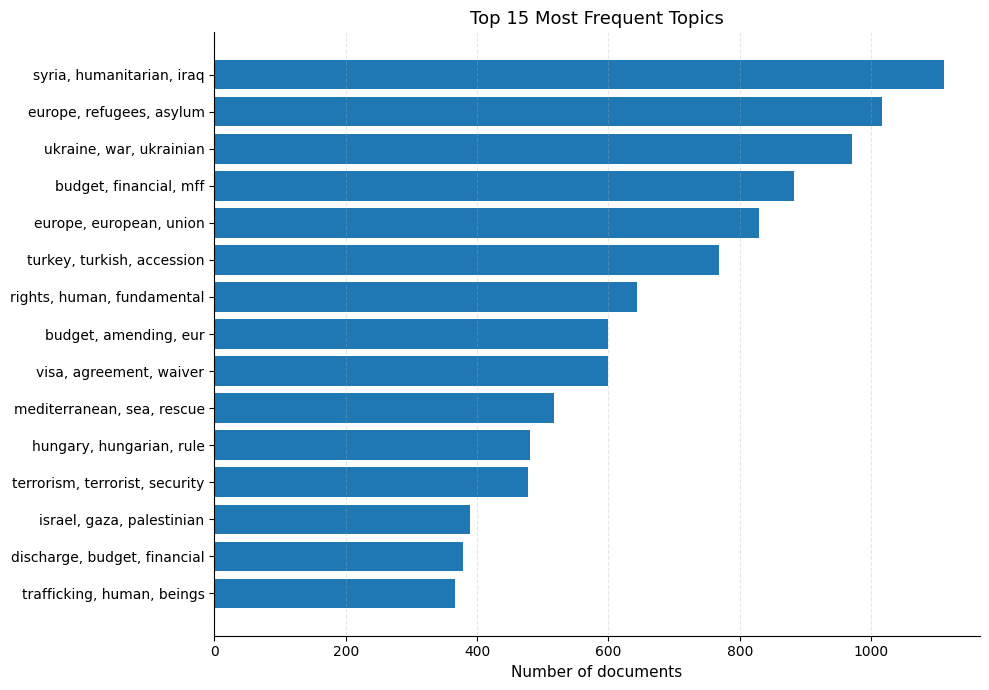

In [45]:
import matplotlib.pyplot as plt

# Get topic info
topic_info = topic_model2.get_topic_info()

# Remove outlier topic
topic_info = topic_info[topic_info["Topic"] != -1].copy()

# Select top 15 topics
top15 = topic_info.sort_values("Count", ascending=True).tail(15)

# Build readable labels (top 3 keywords per topic)
labels = [
    ", ".join([word for word, _ in topic_model2.get_topic(t)[:3]])
    for t in top15["Topic"]
]

# Plot
plt.figure(figsize=(10, 7))

bars = plt.barh(labels, top15["Count"])

# Title and labels
plt.title("Top 15 Most Frequent Topics", fontsize=13)
plt.xlabel("Number of documents", fontsize=11)

# Improve readability
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
topic_period = pd.crosstab(
    df["topic"],
    df["period"],
    normalize="columns"
) * 100



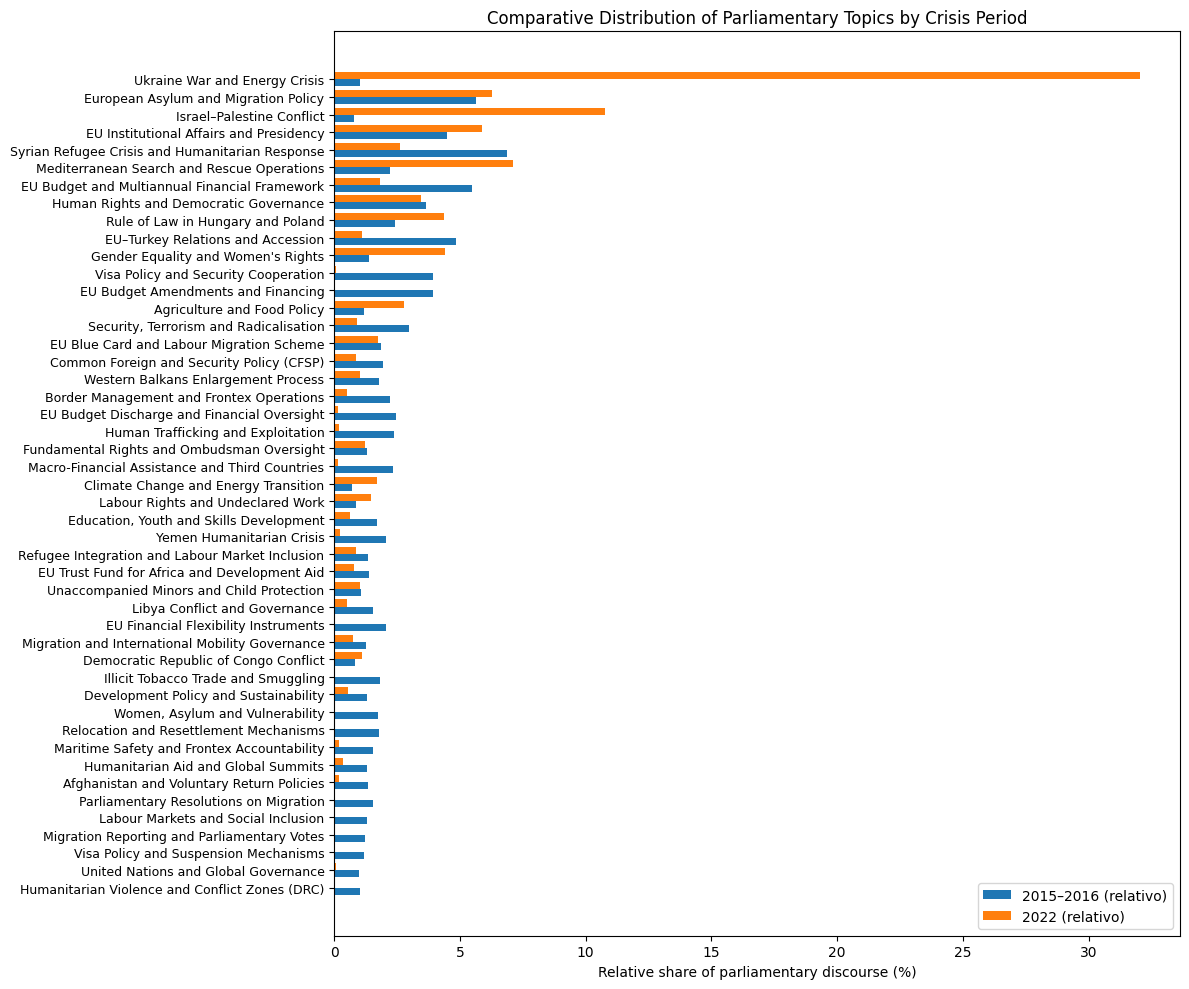

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

plot_df = topic_period.copy()

# =========================
# 1. Garantir que -1 está fora (caso exista como índice)
# =========================
plot_df = plot_df.drop(index=-1, errors="ignore")

# =========================
# 2. Normalização (peso relativo dentro de cada período)
# =========================
plot_df["migration_crisis_norm"] = (
    plot_df["migration_crisis"] / plot_df["migration_crisis"].sum()
)

plot_df["ukraine_refugees_norm"] = (
    plot_df["ukraine_refugees"] / plot_df["ukraine_refugees"].sum()
)

# =========================
# 3. Diferença absoluta (agora baseada em valores relativos)
# =========================
plot_df["difference"] = (
    plot_df["migration_crisis_norm"] - plot_df["ukraine_refugees_norm"]
).abs()

# =========================
# 4. Top 20 maiores diferenças
# =========================
plot_df = plot_df.sort_values("difference", ascending=False)

# (opcional mas útil se quiseres mesmo top 20)
#plot_df = plot_df.head(20)

# =========================
# 5. Labels
# =========================
plot_df["label"] = plot_df.index.map(topic_labels)

plot_df["label"] = plot_df["label"].fillna(
    pd.Series(plot_df.index.astype(str), index=plot_df.index)
)

# =========================
# 6. Ordenação FINAL (para gráfico legível)
# =========================
plot_df["mean"] = (
    plot_df["migration_crisis_norm"] + plot_df["ukraine_refugees_norm"]
) / 2

plot_df = plot_df.sort_values("mean", ascending=True)

# =========================
# 7. Plot (AGORA EM PERCENTAGEM RELATIVA)
# =========================
fig, ax = plt.subplots(figsize=(12, 10))

y = range(len(plot_df))

ax.barh(
    [i - 0.2 for i in y],
    plot_df["migration_crisis_norm"] * 100,
    height=0.4,
    label="2015–2016 (relativo)"
)

ax.barh(
    [i + 0.2 for i in y],
    plot_df["ukraine_refugees_norm"] * 100,
    height=0.4,
    label="2022 (relativo)"
)

ax.set_yticks(list(y))
ax.set_yticklabels(plot_df["label"], fontsize=9)

ax.set_xlabel("Relative share of parliamentary discourse (%)")
ax.set_title("Comparative Distribution of Parliamentary Topics by Crisis Period")

ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
topic_to_frame = {
    0: "Humanitarian & Human Rights",
    1: "Humanitarian & Human Rights",
    2: "Geopolitical Context & External Relations",
    3: "EU Governance, Policy & Institutional Framework",
    4: "EU Governance, Policy & Institutional Framework",
    5: "Geopolitical Context & External Relations",
    6: "Humanitarian & Human Rights",
    7: "EU Governance, Policy & Institutional Framework",
    8: "EU Governance, Policy & Institutional Framework",
    9: "Security & Border Control",
    10: "Geopolitical Context & External Relations",
    11: "Security & Border Control",
    12: "Geopolitical Context & External Relations",
    13: "EU Governance, Policy & Institutional Framework",
    14: "Humanitarian & Human Rights",
    15: "Geopolitical Context & External Relations",
    16: "Security & Border Control",
    17: "EU Governance, Policy & Institutional Framework",
    18: "Humanitarian & Human Rights",
    19: "Geopolitical Context & External Relations",
    20: "Humanitarian & Human Rights",
    21: "EU Governance, Policy & Institutional Framework",
    22: "Geopolitical Context & External Relations",
    23: "Security & Border Control",
    24: "EU Governance, Policy & Institutional Framework",
    25: "Security & Border Control",
    26: "Humanitarian & Human Rights",
    27: "EU Governance, Policy & Institutional Framework",
    28: "Geopolitical Context & External Relations",
    29: "Security & Border Control",
    30: "Security & Border Control",
    31: "EU Governance, Policy & Institutional Framework",
    32: "Humanitarian & Human Rights",
    33: "Security & Border Control",
    34: "Geopolitical Context & External Relations",
    35: "EU Governance, Policy & Institutional Framework",
    36: "EU Governance, Policy & Institutional Framework",
    37: "Humanitarian & Human Rights",
    38: "EU Governance, Policy & Institutional Framework",
    39: "Humanitarian & Human Rights",
    40: "Security & Border Control",
    41: "EU Governance, Policy & Institutional Framework",
    42: "EU Governance, Policy & Institutional Framework",
    43: "Humanitarian & Human Rights",
    44: "Geopolitical Context & External Relations",
    45: "Geopolitical Context & External Relations",
    46: "EU Governance, Policy & Institutional Framework"
}

In [84]:
topic_to_frame = {
    # 🔵 Security & Border Control
    9: "Security & Border Control",
    11: "Security & Border Control",
    16: "Security & Border Control",
    23: "Security & Border Control",
    25: "Security & Border Control",
    29: "Security & Border Control",
    30: "Security & Border Control",
    33: "Security & Border Control",
    40: "Security & Border Control",

    # 🟢 Humanitarian & Protection
    0: "Humanitarian & Protection",
    1: "Humanitarian & Protection",
    6: "Humanitarian & Protection",
    14: "Humanitarian & Protection",
    18: "Humanitarian & Protection",
    20: "Humanitarian & Protection",
    26: "Humanitarian & Protection",
    32: "Humanitarian & Protection",
    37: "Humanitarian & Protection",
    39: "Humanitarian & Protection",
    43: "Humanitarian & Protection",

    # 🔴 Geopolitical & Conflict System
    2: "Geopolitical & Conflict System",
    5: "Geopolitical & Conflict System",
    10: "Geopolitical & Conflict System",
    12: "Geopolitical & Conflict System",
    15: "Geopolitical & Conflict System",
    19: "Geopolitical & Conflict System",
    22: "Geopolitical & Conflict System",
    28: "Geopolitical & Conflict System",
    44: "Geopolitical & Conflict System",
    45: "Geopolitical & Conflict System",

    # 🟡 Migration Governance & Mobility Policy
    3: "Migration Governance & Mobility Policy",
    4: "Migration Governance & Mobility Policy",
    7: "Migration Governance & Mobility Policy",
    8: "Migration Governance & Mobility Policy",
    13: "Migration Governance & Mobility Policy",
    17: "Migration Governance & Mobility Policy",
    21: "Migration Governance & Mobility Policy",
    31: "Migration Governance & Mobility Policy",
    34: "Migration Governance & Mobility Policy",
    41: "Migration Governance & Mobility Policy",

    # 🟣 Socioeconomic & Structural Policies
    24: "Socioeconomic & Structural Policies",
    27: "Socioeconomic & Structural Policies",
    35: "Socioeconomic & Structural Policies",
    36: "Socioeconomic & Structural Policies",
    38: "Socioeconomic & Structural Policies",
    42: "Socioeconomic & Structural Policies",
    46: "Socioeconomic & Structural Policies"
}


df['frame'] = df['topic'].map(topic_to_frame)

frame_by_period = (
    df.groupby(['period', 'frame'])
      .size()
      .reset_index(name='count')
)

frame_by_period['percentage'] = frame_by_period.groupby('period')['count'].transform(
    lambda x: x / x.sum() * 100
)

frame_by_period

,period,frame,count,percentage
0,migration_crisis,Geopolitical & Conflict System,2817,18.508541
1,migration_crisis,Humanitarian & Protection,4337,28.495401
2,migration_crisis,Migration Governance & Mobility Policy,4269,28.048620
3,migration_crisis,Security & Border Control,2521,16.563732
4,migration_crisis,Socioeconomic & Structural Policies,1276,8.383706
5,ukraine_refugees,Geopolitical & Conflict System,1319,52.031558
6,ukraine_refugees,Humanitarian & Protection,493,19.447732
7,ukraine_refugees,Migration Governance & Mobility Policy,285,11.242604
8,ukraine_refugees,Security & Border Control,253,9.980276
9,ukraine_refugees,Socioeconomic & Structural Policies,185,7.297830


In [85]:
pivot = frame_by_period.pivot(
    index='frame',
    columns='period',
    values='percentage'
).fillna(0)

pivot

period,migration_crisis,ukraine_refugees
frame,,
Geopolitical & Conflict System,18.508541,52.031558
Humanitarian & Protection,28.495401,19.447732
Migration Governance & Mobility Policy,28.048620,11.242604
Security & Border Control,16.563732,9.980276
Socioeconomic & Structural Policies,8.383706,7.297830


In [88]:
import pandas as pd

# definir tamanho mínimo entre períodos
min_n = df.groupby('period').size().min()

balanced_df = (
    df.groupby('period', group_keys=False)
      .apply(lambda x: x.sample(n=min_n, random_state=42))
)

balanced_df['frame'] = balanced_df['topic'].map(topic_to_frame)

frame_by_period_balanced = (
    balanced_df.groupby(['period', 'frame'])
      .size()
      .reset_index(name='count')
)

frame_by_period_balanced['percentage'] = frame_by_period_balanced.groupby('period')['count'].transform(
    lambda x: x / x.sum() * 100
)

frame_by_period_balanced

C:\Users\marta\AppData\Local\Temp\ipykernel_13716\1094607430.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min_n, random_state=42))


,period,frame,count,percentage
0,migration_crisis,Geopolitical & Conflict System,441,17.569721
1,migration_crisis,Humanitarian & Protection,762,30.358566
2,migration_crisis,Migration Governance & Mobility Policy,702,27.968127
3,migration_crisis,Security & Border Control,400,15.936255
4,migration_crisis,Socioeconomic & Structural Policies,205,8.167331
5,ukraine_refugees,Geopolitical & Conflict System,1319,52.031558
6,ukraine_refugees,Humanitarian & Protection,493,19.447732
7,ukraine_refugees,Migration Governance & Mobility Policy,285,11.242604
8,ukraine_refugees,Security & Border Control,253,9.980276
9,ukraine_refugees,Socioeconomic & Structural Policies,185,7.297830


In [89]:
pivot = frame_by_period_balanced.pivot(
    index='frame',
    columns='period',
    values='percentage'
).fillna(0)

pivot

period,migration_crisis,ukraine_refugees
frame,,
Geopolitical & Conflict System,17.569721,52.031558
Humanitarian & Protection,30.358566,19.447732
Migration Governance & Mobility Policy,27.968127,11.242604
Security & Border Control,15.936255,9.980276
Socioeconomic & Structural Policies,8.167331,7.297830


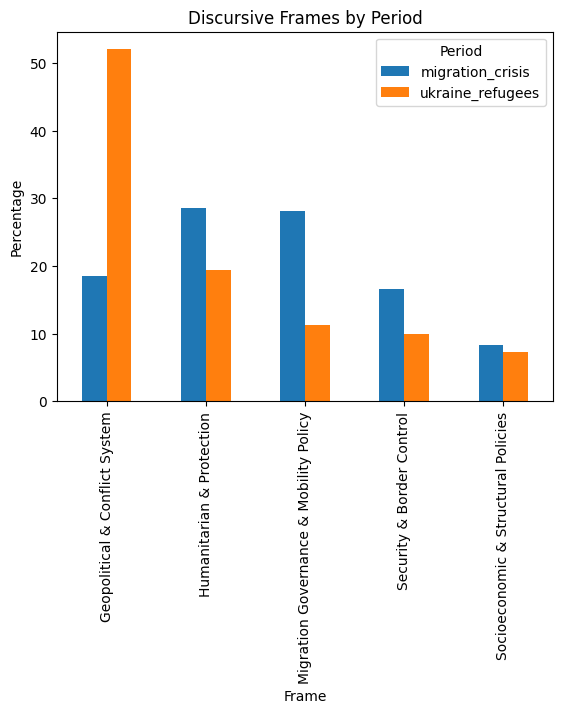

In [86]:
import matplotlib.pyplot as plt

pivot.plot(kind='bar')

plt.title('Discursive Frames by Period')
plt.xlabel('Frame')
plt.ylabel('Percentage')
plt.legend(title='Period')
plt.show()

In [107]:
import re

def clean_speech(text):

    text = str(text).lower()

    # remover padrões parlamentares
    patterns = [
        r"madam president",
        r"mr president",
        r"president",
        r"on behalf of.*?group",
        r"blue[- ]card question",
        r"answer to a blue[- ]card",
        r"commission",
        r"council",
        r"parliament",
        r"ladies and gentlemen"
    ]

    for p in patterns:
        text = re.sub(p, " ", text)

    # remover números e pontuação
    text = re.sub(r"[^a-z\s]", " ", text)

    # remover espaços múltiplos
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [108]:
df['speech_clean_final'] = df['speech_en_clean'].apply(clean_speech)

In [124]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

base = set(ENGLISH_STOP_WORDS)

parliament_noise = {
    "european", "europe", "eu", "union",
    "commission", "parliament", "member", "states",
    "report", "writing", "voted",
    "mr", "madam", "president",
    "council", "committee",

    # MUITO IMPORTANTE (corrige o teu problema atual)
    "need", "people", "like", "would", "could",
    "also", "one", "two", "time", "today"
}

custom_stopwords = base.union(parliament_noise)
custom_stopwords = list(custom_stopwords)

In [125]:
def top_words_final(df, frame, period):

    texts = df[
        (df['frame'] == frame) &
        (df['period'] == period)
    ]['speech_clean_final'].dropna()

    if len(texts) < 2:
        return pd.DataFrame({'word': [], 'freq': []})

    vectorizer = CountVectorizer(
        stop_words=custom_stopwords,
        max_features=500
    )

    X = vectorizer.fit_transform(texts)

    words = pd.DataFrame({
        "word": vectorizer.get_feature_names_out(),
        "freq": X.sum(axis=0).A1
    })

    return words.sort_values("freq", ascending=False).head(20)

In [126]:
frames = df['frame'].unique()

for frame in frames:

    print("="*80)
    print(frame)
    print("="*80)

    print("\n2015–2016\n")

    print(
        top_words_final(
            df,
            frame,
            "migration_crisis",
        )
    )

    print("\n2022\n")

    print(
        top_words_final(
            df,
            frame,
            "ukraine_refugees",
        )
    )

    print("\n\n")

Security & Border Control

2015–2016

            word  freq
51        border  1254
52       borders  1191
18        agency  1072
287    migration  1070
465      tobacco  1069
181      frontex   984
101    countries   977
409     security   930
155     external   879
286     migrants   868
376     refugees   819
97   cooperation   775
38        asylum   754
94       control   747
396       rights   732
280     measures   728
455    terrorism   722
352     proposal   709
301          new   697
439      support   696

2022

              word  freq
284      migration   266
400            sea   204
182        frontex   172
211          human   165
259          lives   159
381          right   157
277  mediterranean   155
283       migrants   145
367         rescue   138
46         borders   134
29          asylum   133
237          italy   127
382         rights   123
421     solidarity   121
86       countries   119
246            law   113
493           work   110
301           ngos   1

To Delete

In [85]:
import numpy as np

df = df.copy()
df["embedding"] = list(embeddings)

In [203]:
migration_topics = [
    1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24,
    25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48

]

df_mig = df[df["topic"].isin(migration_topics)].copy()

df_mig = df_mig.reset_index(drop=True)
df_mig["embedding"] = list(embeddings[:len(df_mig)])

In [204]:
frames = {
    "security": "migration is a threat to security, borders and public order",
    "humanitarian": "refugees need protection due to war, persecution and humanitarian crisis",
    "solidarity": "EU member states should share responsibility for asylum seekers",
    "governance": "migration is managed through policies, procedures and administrative systems",
    "external_cooperation": "migration is managed through cooperation with third countries and external agreements",
    "rights": "migration is framed in terms of human rights and legal asylum obligations",
    "crisis": "migration is described as a crisis, emergency or exceptional situation"
}

frames_v2 = {
    "security": "migration is associated with border control and security concerns",
    "humanitarian": "refugees require protection and international assistance due to conflict",
    "solidarity": "EU states share responsibility for asylum seekers and relocation",
    "governance": "migration is managed through EU policies and administrative systems",
    "external_cooperation": "migration is managed through agreements with third countries",
    "rights": "migration is related to human rights and legal obligations",
    "crisis": "migration is described as an emergency or crisis situation"
}

frame_embeddings = {
    k: model.encode(v)
    for k, v in frames.items()
}

frame_embeddings2 = {
    k: model.encode(v)
    for k, v in frames_v2.items()
}

In [205]:
from sklearn.metrics.pairwise import cosine_similarity

def get_frame_scores(doc_emb):
    scores = {}

    for frame, frame_emb in frame_embeddings.items():
        scores[frame] = float(
            cosine_similarity([doc_emb], [frame_emb])[0][0]
        )

    return scores

def get_frame_scores2(doc_emb):
    scores = {}

    for frame, frame_emb in frame_embeddings2.items():
        scores[frame] = float(
            cosine_similarity([doc_emb], [frame_emb])[0][0]
        )

    return scores


df_mig = df_mig.copy()

df_mig["frame_scores"] = df_mig["embedding"].apply(get_frame_scores)

df_mig["frame_scores_robust"] = df_mig["embedding"].apply(get_frame_scores2)


In [206]:
frame_df = df_mig["frame_scores"].apply(pd.Series)

frame_df2 = df_mig["frame_scores_robust"].apply(pd.Series)

df_mig = pd.concat([df_mig, frame_df, frame_df2], axis=1)

df_mig[['frame_scores', 'frame_scores_robust']]



,frame_scores,frame_scores_robust
0,"{'security': 0.4393496513366699, 'humanitarian...","{'security': 0.29211097955703735, 'humanitaria..."
1,"{'security': 0.3578365445137024, 'humanitarian...","{'security': 0.2520110607147217, 'humanitarian..."
2,"{'security': 0.42629802227020264, 'humanitaria...","{'security': 0.29574090242385864, 'humanitaria..."
3,"{'security': 0.488582968711853, 'humanitarian'...","{'security': 0.385795921087265, 'humanitarian'..."
4,"{'security': 0.6328209638595581, 'humanitarian...","{'security': 0.5301339626312256, 'humanitarian..."
...,...,...
18955,"{'security': 0.4996301531791687, 'humanitarian...","{'security': 0.46943825483322144, 'humanitaria..."
18956,"{'security': 0.4736630320549011, 'humanitarian...","{'security': 0.44072771072387695, 'humanitaria..."
18957,"{'security': 0.5477460622787476, 'humanitarian...","{'security': 0.4839824438095093, 'humanitarian..."
18958,"{'security': 0.4156026244163513, 'humanitarian...","{'security': 0.35907846689224243, 'humanitaria..."


In [207]:
base_df = pd.DataFrame(df_mig["frame_scores"].tolist()).add_prefix("base_")
robust_df = pd.DataFrame(df_mig["frame_scores_robust"].tolist()).add_prefix("robust_")

df_mig = pd.concat([df_mig, base_df, robust_df], axis=1)

In [208]:
df_mig["dominant_frame"] = df_mig[base_cols].idxmax(axis=1)
df_mig["dominant_frame_robust"] = df_mig[robust_cols].idxmax(axis=1)

# remover prefixos "base_" e "robust_"
df_mig["dominant_frame_clean"] = df_mig["dominant_frame"].str.replace("base_", "", regex=False)
df_mig["dominant_frame_robust_clean"] = df_mig["dominant_frame_robust"].str.replace("robust_", "", regex=False)


In [209]:
from scipy.stats import pearsonr
import numpy as np

corr_results = {}

frame_names = [
    "security",
    "humanitarian",
    "solidarity",
    "governance",
    "external_cooperation",
    "rights",
    "crisis"
]

print("\n=== FRAME STABILITY (Pearson correlation) ===")

for f in frame_names:
    
    base = df_mig[f"base_{f}"]
    robust = df_mig[f"robust_{f}"]

    # 👉 FORÇA conversão para 1D float (muito importante)
    base = np.asarray(base).astype(float)
    robust = np.asarray(robust).astype(float)

    # remover NaNs se existirem
    mask = ~np.isnan(base) & ~np.isnan(robust)

    r, _ = pearsonr(base[mask], robust[mask])

    corr_results[f] = r
    print(f"{f}: {r:.4f}")

avg_stability = np.mean(list(corr_results.values()))
print("\nAverage frame stability:", round(avg_stability, 4))

from scipy.stats import spearmanr
import numpy as np

print("\n=== SPEARMAN FRAME STABILITY ===")

for f in frame_names:
    
    base = df_mig[f"base_{f}"].to_numpy(dtype=float)
    robust = df_mig[f"robust_{f}"].to_numpy(dtype=float)

    # remover NaNs (CRÍTICO)
    mask = ~np.isnan(base) & ~np.isnan(robust)

    r, _ = spearmanr(base[mask], robust[mask])

    # garantir que é escalar
    r = float(r)

    print(f"{f}: {r:.4f}")

# remover prefixos "base_" e "robust_"
df_mig["dominant_frame_clean"] = df_mig["dominant_frame"].str.replace("base_", "", regex=False)
df_mig["dominant_frame_robust_clean"] = df_mig["dominant_frame_robust"].str.replace("robust_", "", regex=False)

# comparação correta
changes = df_mig["dominant_frame_clean"] != df_mig["dominant_frame_robust_clean"]

n_changes = changes.sum()
pct_changes = changes.mean() * 100

print("Number of changed dominant frames:", n_changes)
print("Percentage of changes:", round(pct_changes, 2), "%")


=== FRAME STABILITY (Pearson correlation) ===
security: 0.9565
humanitarian: 0.9857
solidarity: 0.9830
governance: 0.8065
external_cooperation: 0.9815
rights: 0.9691
crisis: 0.9969

Average frame stability: 0.9542

=== SPEARMAN FRAME STABILITY ===
security: 0.9569
humanitarian: 0.9857
solidarity: 0.9825
governance: 0.8096
external_cooperation: 0.9799
rights: 0.9705
crisis: 0.9968
Number of changed dominant frames: 6821
Percentage of changes: 35.98 %


In [210]:
import pandas as pd

transition = pd.crosstab(
    df_mig["dominant_frame_clean"],
    df_mig["dominant_frame_robust_clean"],
    normalize="index"
)

transition

dominant_frame_robust_clean,crisis,external_cooperation,governance,humanitarian,rights,security,solidarity
dominant_frame_clean,,,,,,,
crisis,0.586207,0.000000,0.172414,0.120690,0.000000,0.051724,0.068966
external_cooperation,0.000000,0.452413,0.339088,0.026118,0.024790,0.004869,0.152722
governance,0.000000,0.038462,0.846154,0.038462,0.038462,0.038462,0.000000
humanitarian,0.000000,0.000566,0.000566,0.931522,0.002830,0.000000,0.064516
rights,0.000974,0.020458,0.183147,0.127131,0.244033,0.006819,0.417438
security,0.004352,0.026110,0.295909,0.121845,0.050044,0.162315,0.339426
solidarity,0.000190,0.003715,0.137823,0.040385,0.003143,0.001238,0.813506


In [211]:
df_examples = (
    df_mig.groupby("frame", group_keys=False)
    .sample(2, random_state=1)
    .reset_index(drop=True)
)					


In [212]:
pd.crosstab(df_mig["year"], df_mig["dominant_frame"], normalize="index")

dominant_frame,base_crisis,base_external_cooperation,base_governance,base_humanitarian,base_rights,base_security,base_solidarity
year,,,,,,,
2015.0,0.004424,0.085343,0.001998,0.113601,0.099329,0.131440,0.563865
2016.0,0.001980,0.122182,0.001320,0.090949,0.118223,0.115473,0.549874
2022.0,0.004337,0.182169,0.000000,0.049639,0.083373,0.130120,0.550361
2023.0,0.000000,0.254111,0.000000,0.058296,0.139013,0.064275,0.484305
2024.0,0.000000,0.017241,0.000000,0.017241,0.137931,0.120690,0.706897


In [213]:
df_mig["year"].value_counts().sort_index()

year
2015.0    7007
2016.0    9093
2022.0    2075
2023.0     669
2024.0     116
Name: count, dtype: int64

In [143]:
import pandas as pd

frames = list(df_mig["frame_scores"].iloc[0].keys())

# expandir frame_scores em colunas
frame_df = pd.DataFrame(df_mig["frame_scores"].tolist())
frame_df["year"] = df_mig["year"]  # ajusta se o nome for diferente

# média por ano
year_means = frame_df.groupby("year")[frames].mean()

year_means

,security,humanitarian,solidarity,governance,external_cooperation,rights,crisis
year,,,,,,,
2015.0,0.356887,0.329199,0.398560,0.172138,0.337902,0.362445,0.268359
2016.0,0.393171,0.377225,0.437871,0.198483,0.369590,0.412489,0.297075
2022.0,0.340886,0.302886,0.387672,0.121566,0.287657,0.347909,0.216780
2023.0,0.351794,0.267107,0.394927,0.158611,0.316237,0.339357,0.206453


In [144]:
diff = year_means.loc[2022] - year_means.loc[2015]

diff.sort_values(ascending=False)

solidarity             -0.010888
rights                 -0.014537
security               -0.016001
humanitarian           -0.026313
external_cooperation   -0.050245
governance             -0.050572
crisis                 -0.051579
dtype: float64

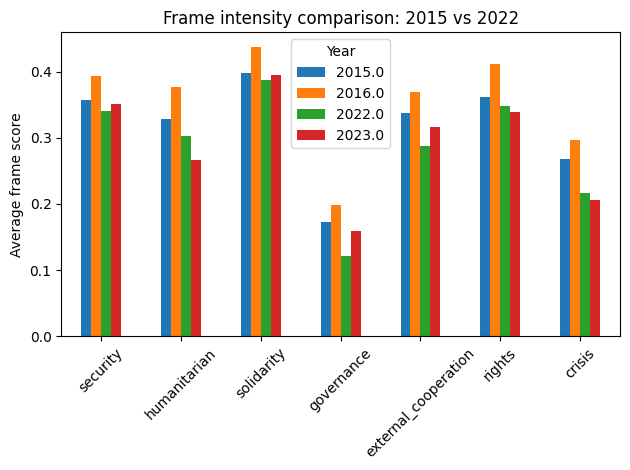

In [145]:
import matplotlib.pyplot as plt

year_means.T.plot(kind="bar")
plt.title("Frame intensity comparison: 2015 vs 2022")
plt.ylabel("Average frame score")
plt.xticks(rotation=45)
plt.legend(title="Year")
plt.tight_layout()
plt.show()

In [146]:
from scipy.stats import ttest_ind

results = []

for f in frames:
    v2015 = frame_df[frame_df["year"] == 2015][f]
    v2022 = frame_df[frame_df["year"] == 2022][f]
    
    stat, p = ttest_ind(v2015, v2022, nan_policy="omit")
    
    results.append({
        "frame": f,
        "mean_2015": v2015.mean(),
        "mean_2022": v2022.mean(),
        "p_value": p
    })

pd.DataFrame(results).sort_values("p_value")

,frame,mean_2015,mean_2022,p_value
3,governance,0.172138,0.121566,0.000028
6,crisis,0.268359,0.216780,0.002352
4,external_cooperation,0.337902,0.287657,0.009123
1,humanitarian,0.329199,0.302886,0.311409
5,rights,0.362445,0.347909,0.520276
0,security,0.356887,0.340886,0.525320
2,solidarity,0.398560,0.387672,0.633510
